# 01. EDA de Ratings y Catálogo

In [1]:
from pathlib import Path
import sys
import warnings

warnings.filterwarnings('ignore')

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from IPython.display import display
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 5)

from src.utils.recsys_utils import ensure_dir, load_clean_data, summarize_tables

In [2]:
imdb, movielens = load_clean_data(source="movielens", use_cache=True)
reports_dir = ensure_dir(ROOT / 'reports')
figures_dir = ensure_dir(reports_dir / 'figures')
tables_dir = ensure_dir(reports_dir / 'tables')


[19:47:31] INFO - Iniciando pipeline de carga y limpieza | source=movielens | use_cache=True | refresh_cache=False
[19:47:31] INFO - No existe cache limpia para movielens
[19:47:31] INFO - Se omite carga de IMDb porque no fue solicitado
[19:47:31] INFO - No hay cache utilizable de MovieLens. Se cargara desde origen.
[19:47:31] INFO - Buscando datasets | source=movielens
[19:47:31] INFO - Explorando carpeta MovieLens: /Users/chperezpelaez/Documents/Github/dmc-tp1-rec-sys/data/mov_lens
[19:47:31] INFO - Cargando MovieLens: links.csv
[19:47:31] INFO - MovieLens cargado: links.csv | filas=87585 columnas=3
[19:47:31] INFO - Cargando MovieLens: movies.csv
[19:47:31] INFO - MovieLens cargado: movies.csv | filas=87585 columnas=3
[19:47:31] INFO - Cargando MovieLens: ratings.csv
[19:47:34] INFO - MovieLens cargado: ratings.csv | filas=32000204 columnas=4
[19:47:34] INFO - Cargando MovieLens: tags.csv
[19:47:35] INFO - MovieLens cargado: tags.csv | filas=2000072 columnas=4
[19:47:35] INFO - Carg

## Carga inicial y resumen de tablas


In [3]:
summary_df = summarize_tables(imdb, movielens)
display(summary_df)
summary_df.to_csv(tables_dir / 'eda_table_inventory.csv', index=False)

,source,table,rows,columns
0,MovieLens,links,87585,4
1,MovieLens,movies,87585,6
2,MovieLens,ratings,32000204,4
3,MovieLens,tags,2000072,4


## Preparar tablas principales de MovieLens

Aquí se construyen las vistas de trabajo para ratings, películas, tags y links.


In [4]:
ratings = movielens['ratings'].copy()
movies = movielens['movies'].copy()
tags = movielens['tags'].copy()
links = movielens['links'].copy()

catalog_summary = pd.DataFrame([
    {'metric': 'ratings_rows', 'value': len(ratings)},
    {'metric': 'users', 'value': ratings['userId'].nunique()},
    {'metric': 'movies_with_ratings', 'value': ratings['movieId'].nunique()},
    {'metric': 'catalog_movies', 'value': movies['movieId'].nunique()},
    {'metric': 'tag_rows', 'value': len(tags)},
    {'metric': 'movies_with_tags', 'value': tags['movieId'].nunique()},
])
display(catalog_summary)
catalog_summary.to_csv(tables_dir / 'eda_catalog_summary.csv', index=False)


,metric,value
0,ratings_rows,32000204
1,users,200948
2,movies_with_ratings,84432
3,catalog_movies,87585
4,tag_rows,2000072
5,movies_with_tags,51323


## Distribución de ratings y actividad de usuarios/items

Este bloque permite cuantificar la dispersión de la matriz usuario-item y evidenciar la cola larga del catálogo.


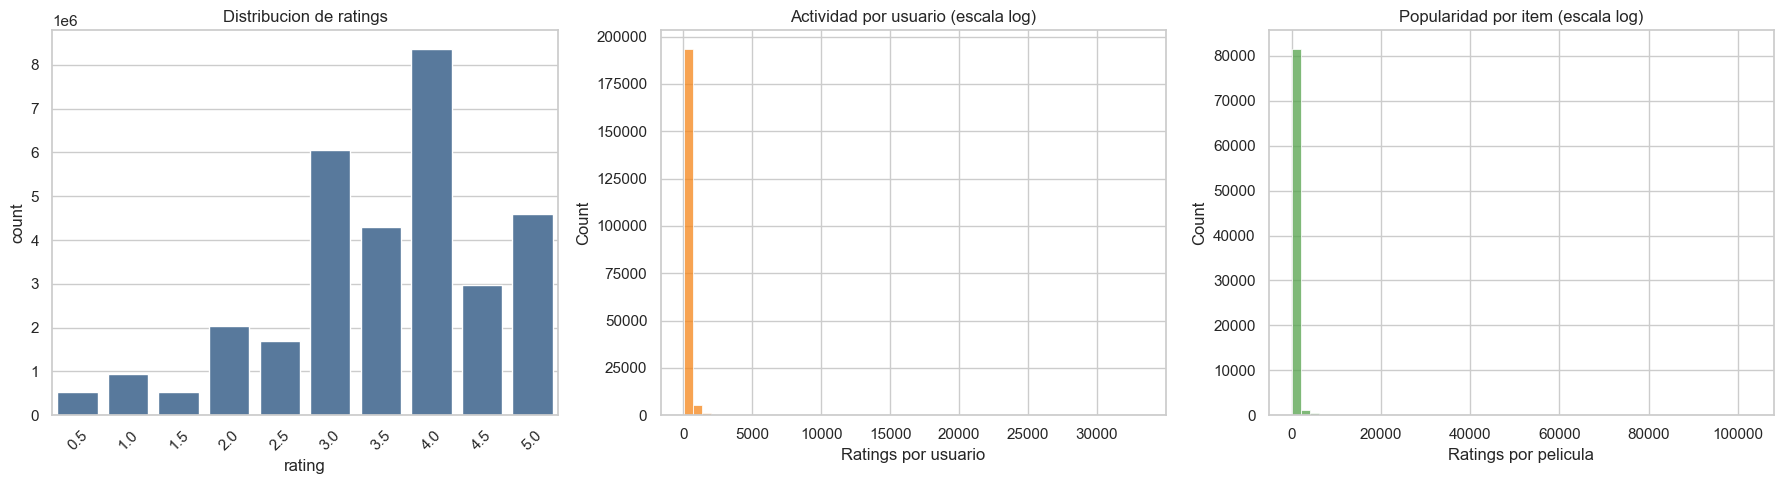

,metric,value
0,matrix_sparsity,0.998114
1,median_ratings_per_user,73.000000
2,median_ratings_per_item,5.000000


In [5]:
rating_dist = ratings['rating'].value_counts().sort_index().rename_axis('rating').reset_index(name='count')
user_activity = ratings.groupby('userId').size().rename('n_ratings').reset_index()
item_activity = ratings.groupby('movieId').size().rename('n_ratings').reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=rating_dist, x='rating', y='count', ax=axes[0], color='#4C78A8')
axes[0].set_title('Distribucion de ratings')
axes[0].tick_params(axis='x', rotation=45)

sns.histplot(user_activity['n_ratings'], bins=50, ax=axes[1], color='#F58518')
axes[1].set_title('Actividad por usuario (escala log)')
axes[1].set_xlabel('Ratings por usuario')

sns.histplot(item_activity['n_ratings'], bins=50, ax=axes[2], color='#54A24B')
axes[2].set_title('Popularidad por item (escala log)')
axes[2].set_xlabel('Ratings por pelicula')

plt.tight_layout()
plt.savefig(figures_dir / 'eda_ratings_users_items.png', bbox_inches='tight')
plt.show()

sparsity = 1 - (len(ratings) / (ratings['userId'].nunique() * ratings['movieId'].nunique()))
eda_metrics = pd.DataFrame([
    {'metric': 'matrix_sparsity', 'value': sparsity},
    {'metric': 'median_ratings_per_user', 'value': user_activity['n_ratings'].median()},
    {'metric': 'median_ratings_per_item', 'value': item_activity['n_ratings'].median()},
])
display(eda_metrics)
eda_metrics.to_csv(tables_dir / 'eda_interaction_metrics.csv', index=False)


## Géneros, cobertura de tags y evolución temporal

Se usan `movies.csv` y `tags.csv` para caracterizar el catálogo y detectar señales auxiliares para el modelo híbrido.


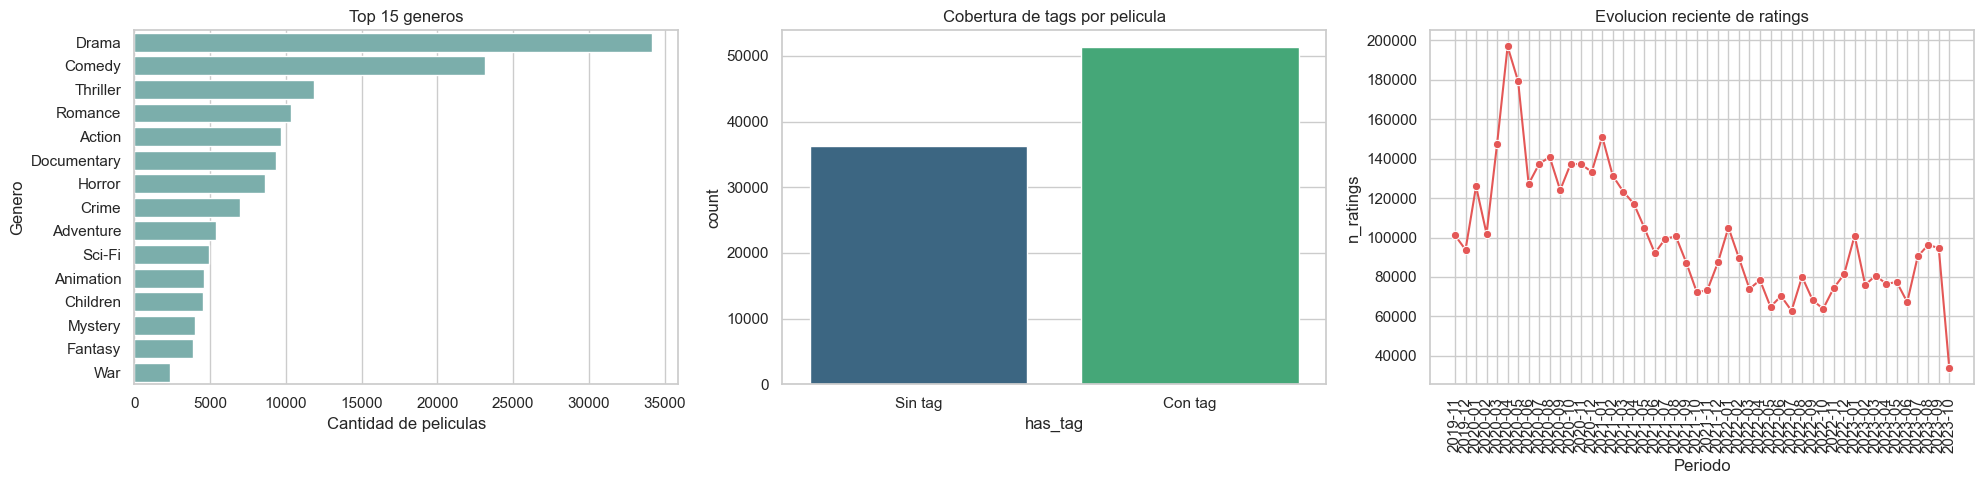

,metric,value
0,share_movies_with_tags,0.585979
1,distinct_genres,19.000000
2,movies_with_imdb_link,1.000000


In [6]:
genre_counts = (
    movies[['movieId', 'genres_list']]
    .explode('genres_list')
    .dropna(subset=['genres_list'])
    .groupby('genres_list')
    .size()
    .sort_values(ascending=False)
    .rename('count')
    .reset_index()
)

tag_coverage = (
    movies[['movieId']]
    .merge(tags[['movieId']].drop_duplicates().assign(has_tag=1), on='movieId', how='left')
    .assign(has_tag=lambda df: df['has_tag'].fillna(0).astype(int))
)

time_series = (
    ratings.assign(year_month=ratings['timestamp'].dt.to_period('M').astype(str))
    .groupby('year_month')
    .size()
    .rename('n_ratings')
    .reset_index()
    .tail(48)
)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
sns.barplot(data=genre_counts.head(15), x='count', y='genres_list', ax=axes[0], color='#72B7B2')
axes[0].set_title('Top 15 generos')
axes[0].set_xlabel('Cantidad de peliculas')
axes[0].set_ylabel('Genero')

sns.countplot(data=tag_coverage, x='has_tag', ax=axes[1], palette='viridis')
axes[1].set_title('Cobertura de tags por pelicula')
axes[1].set_xticklabels(['Sin tag', 'Con tag'])

sns.lineplot(data=time_series, x='year_month', y='n_ratings', marker='o', ax=axes[2], color='#E45756')
axes[2].set_title('Evolucion reciente de ratings')
axes[2].tick_params(axis='x', rotation=90)
axes[2].set_xlabel('Periodo')

plt.tight_layout()
plt.savefig(figures_dir / 'eda_genres_tags_timeline.png', bbox_inches='tight')
plt.show()

coverage_summary = pd.DataFrame([
    {'metric': 'share_movies_with_tags', 'value': tag_coverage['has_tag'].mean()},
    {'metric': 'distinct_genres', 'value': genre_counts['genres_list'].nunique()},
    {'metric': 'movies_with_imdb_link', 'value': links['tconst'].notna().mean()},
])
display(coverage_summary)
coverage_summary.to_csv(tables_dir / 'eda_catalog_coverage.csv', index=False)


## Hallazgos principales

Este bloque deja un resumen compacto que luego puede reutilizarse en la presentación o en el README.


In [7]:
findings = pd.DataFrame([
    {'finding': 'La matriz usuario-item es altamente dispersa', 'value': round(float(sparsity), 6)},
    {'finding': 'Existe cola larga de popularidad', 'value': float(item_activity['n_ratings'].quantile(0.95))},
    {'finding': 'Una fraccion relevante del catalogo tiene tags', 'value': float(tag_coverage['has_tag'].mean())},
])
display(findings)
findings.to_csv(tables_dir / 'eda_findings.csv', index=False)


,finding,value
0,La matriz usuario-item es altamente dispersa,0.998114
1,Existe cola larga de popularidad,1080.000000
2,Una fraccion relevante del catalogo tiene tags,0.585979
